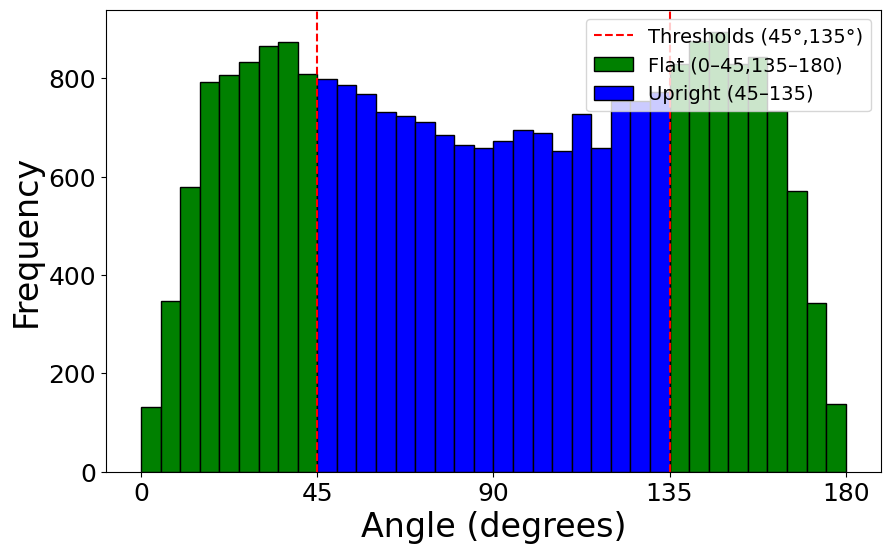

Total frames x niaproof analyzed: 25000
Upright count: 12904
Flat count: 12096
Upright ratio (upright/total): 0.51616
Frame 0:
  NIA 1: angle=62.71°, P2=-0.185, upright
  NIA 2: angle=75.12°, P2=-0.401, upright
  NIA 3: angle=55.50°, P2=-0.019, upright
  NIA 4: angle=118.17°, P2=-0.166, upright
  NIA 5: angle=97.05°, P2=-0.477, upright
  NIA 6: angle=46.45°, P2=0.212, upright
  NIA 7: angle=68.59°, P2=-0.300, upright
  NIA 8: angle=94.16°, P2=-0.492, upright
  NIA 9: angle=70.24°, P2=-0.329, upright
  NIA 10: angle=125.83°, P2=0.014, upright
  NIA 11: angle=64.82°, P2=-0.229, upright
  NIA 12: angle=62.46°, P2=-0.179, upright
  NIA 13: angle=23.55°, P2=0.761, flat
  NIA 14: angle=67.62°, P2=-0.283, upright
  NIA 15: angle=61.66°, P2=-0.162, upright
  NIA 16: angle=78.76°, P2=-0.443, upright
  NIA 17: angle=59.69°, P2=-0.118, upright
  NIA 18: angle=99.39°, P2=-0.460, upright
  NIA 19: angle=100.01°, P2=-0.455, upright
  NIA 20: angle=51.06°, P2=0.093, upright
  NIA 21: angle=90.92°, P2

In [27]:
import os
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt

# === 產生 C1 / C8 index ===
def get_C1_C8_indices(num_niaproof, C1_start=749, C8_start=759
                      , atoms_per_niaproof=48):
    C1_list = [C1_start + i*atoms_per_niaproof for i in range(num_niaproof)]
    C8_list = [C8_start + i*atoms_per_niaproof for i in range(num_niaproof)]
    return C1_list, C8_list

# === 計算多個 niaproof 主軸向量 ===
def calculate_main_axis_multi(traj, C1_list, C8_list):
    num_frames = traj.n_frames
    num_niaproof = len(C1_list)
    main_axis_all = np.zeros((num_frames, num_niaproof, 3))

    for i, (c1, c8) in enumerate(zip(C1_list, C8_list)):
        pos1 = traj.xyz[:, c1, :]
        pos8 = traj.xyz[:, c8, :]
        axis = pos8 - pos1
        norm = np.linalg.norm(axis, axis=1)[:, np.newaxis]
        main_axis_all[:, i, :] = axis / norm

    return main_axis_all

# === 計算 CNT z 向量 ===
def calculate_z_vector(traj, CNT_index1, CNT_index2):
    pos1 = traj.xyz[:, CNT_index1, :]
    pos2 = traj.xyz[:, CNT_index2, :]
    z_vector = pos2 - pos1
    norm = np.linalg.norm(z_vector, axis=1)[:, np.newaxis]
    return z_vector / norm

# === 分析多個 niaproof 方向 (0~180° 判斷) ===
def analyze_orientation_multi(traj, C1_list, C8_list, CNT_index1, CNT_index2):
    main_axis = calculate_main_axis_multi(traj, C1_list, C8_list)  # (frames, niaproof, 3)
    z_vector = calculate_z_vector(traj, CNT_index1, CNT_index2)    # (frames, 3)
    z_vector_expanded = z_vector[:, np.newaxis, :]                  # (frames, 1, 3)

    # dot product → cosθ，範圍 -1~1
    cos_theta = np.sum(main_axis * z_vector_expanded, axis=2)

    # 角度範圍 0–180°
    angles_deg = np.degrees(np.arccos(cos_theta))

    # P2 order parameter
    p2 = 0.5 * (3 * cos_theta**2 - 1)

    # 判斷直立/躺平
    orientation = np.where((angles_deg >= 45) & (angles_deg <= 135), 'upright', 'flat')

    return p2, angles_deg, orientation

# === 載入軌跡 ===
trj_file1 = "/work/jane/nano/NPT/explicit/2mrg_nia50/run_00/mrg_nia_50_i.dcd"
pdb_file1 = "/home/jane/nano/add_ion/NPT/explicit/2mrg_nia50/mrg_nia_50_i.pdb"
traj_CF_straight_o_00 = md.load(trj_file1, top=pdb_file1, stride=20)

# === 設定 niaproof 和 CNT ===
num_niaproof = 50
C1_list, C8_list = get_C1_C8_indices(num_niaproof)
CNT_index1 = 51    # 根據你的系統調整
CNT_index2 = 511   # 根據你的系統調整

# === 執行分析 ===
p2_values, angles, orientation_labels = analyze_orientation_multi(
    traj_CF_straight_o_00, C1_list, C8_list, CNT_index1, CNT_index2
)

# === 計算各幀平均 P2 和直立比例 ===
avg_p2 = np.mean(p2_values, axis=1)
upright_ratio = np.mean(orientation_labels == 'upright', axis=1)

# =====將 angles 展平成一維=======
angles_flat = angles.flatten()

# === Histogram (0–180°) ===
bins = 36  # 每 bin = 5 度
counts, bin_edges = np.histogram(angles_flat, bins=bins, range=(0,180))

# 計算每個 bin 中心
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_width = bin_edges[1] - bin_edges[0]

# 分組 mask
upright_mask = (bin_centers >= 45) & (bin_centers <= 135)
flat_mask = ~upright_mask

plt.figure(figsize=(10,6))

# 畫 histogram：分成直立 / 躺平
plt.bar(bin_centers[flat_mask], counts[flat_mask], width=bar_width, 
        color='green', edgecolor='black', label='Flat (0–45,135–180)')
plt.bar(bin_centers[upright_mask], counts[upright_mask], width=bar_width, 
        color='blue', edgecolor='black', label='Upright (45–135)')

# 閾值線
plt.axvline(45, color='red', linestyle='--')
plt.axvline(135, color='red', linestyle='--', label='Thresholds (45°,135°)')
plt.tick_params(axis='both', which='major', labelsize=18)

# 標籤與標題
plt.xlabel("Angle (degrees)", fontsize=24)
plt.ylabel("Frequency", fontsize=24)
#plt.title("Angle distribution (0–180°), 5°/bin ", fontsize=22)
plt.legend(fontsize=14, loc='upper right')
plt.xticks([0, 45, 90, 135, 180])



plt.show()

# === 統計直立 / 平躺數量 ===
upright_count = np.sum(orientation_labels == 'upright')
flat_count = np.sum(orientation_labels == 'flat')

print(f"Total frames x niaproof analyzed: {orientation_labels.size}")
print(f"Upright count: {upright_count}")
print(f"Flat count: {flat_count}")
print(f"Upright ratio (upright/total): {upright_count/orientation_labels.size}")

# === 範例輸出前 500 幀結果 (每個 sds) ===
for i in range(500):
    print(f"Frame {i}:")
    for j in range(num_niaproof):
        print(f"  NIA {j+1}: angle={angles[i,j]:.2f}°, P2={p2_values[i,j]:.3f}, {orientation_labels[i,j]}")

In [26]:
import pandas as pd

# ===== 整理成 long-format 表格 =====
num_frames = traj_CF_straight_o_00.n_frames

frame_list = []
nia_list = []
angle_list = []
p2_list = []
orientation_list = []

for i in range(num_frames):
    for j in range(num_niaproof):
        frame_list.append(i)
        nia_list.append(j+1)
        angle_list.append(angles[i, j])
        p2_list.append(p2_values[i, j])
        orientation_list.append(orientation_labels[i, j])

df = pd.DataFrame({
    "Frame": frame_list,
    "NIA_ID": nia_list,
    "Angle_deg": angle_list,
    "P2": p2_list,
    "Orientation": orientation_list
})

# ===== 存成 CSV =====
output_file = "200nia.csv"
df.to_csv(output_file, index=False)

print(f"Data saved to {output_file}")

Data saved to 200nia.csv


In [29]:
# === 4. 統計計算 (包含標準差) ===
# 計算每一幀的直立比例
upright_mask = (orientation_labels == 'upright')
upright_ratio_per_frame = np.mean(upright_mask, axis=1)

# 計算總平均與標準差
mean_ratio = np.mean(upright_ratio_per_frame)
std_ratio = np.std(upright_ratio_per_frame)    #對「所有幀的比例」算標準差
avg_p2_per_frame = np.mean(p2_values, axis=1)

print("\n--- Statistics Summary ---")
print(f"Total Snapshots: {traj_CF_straight_o_00.n_frames}")
print(f"Mean Upright Ratio: {mean_ratio:.4f} (or {mean_ratio*100:.2f}%)")
print(f"Standard Deviation of Ratio: {std_ratio:.4f}")
print(f"Overall Average P2: {np.mean(p2_values):.4f}")
print("--------------------------\n")


--- Statistics Summary ---
Total Snapshots: 500
Mean Upright Ratio: 0.5162 (or 51.62%)
Standard Deviation of Ratio: 0.0824
Overall Average P2: 0.2105
--------------------------

